Now the goal is to quantify the strengths of the semi finalists so that we can then predict the finalists based on semi finals boulders and then the podium

A benefit of also grouping the qualifiers first is that, it is more likely they've had more experience since they would have attended more semi finals (since we base it off of semi final attendance rate) and so we have more data backing the future predictions


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

predicted_SF = pd.read_csv("SemiFinalists.csv")["Athlete_ID"].tolist()

In [ ]:
# Obtain the data frames first

pct_of_best = pd.read_csv("Boulder_Results_with_PctOfBest.csv")
style = pd.read_csv("BoulderStyle.csv")

# Clean the files just in case since I uploaded them on sheets
pct_of_best["Boulder_Num"] = pct_of_best["Boulder_Num"].astype(int)
style["Boulder_Num"] = style["Boulder_Num"].astype(int)


# Combine athlete data per boulder as well as boulder style together
merged = pct_of_best.merge(style, on=["Event_ID", "Round", "Boulder_Num"], how="inner")

style_labs = ["Slab", "Coordination", "Power", "Compression", "Dynamic", "Press"]

# The plan is to create a 'profile' for each climber, assigning a numerical value
# that acts as a score to rate each climber's strengths according to each style.
# We multiply Pct_Of_Best by how much a boulder leans into each style.
# This is then how much it contributes to a climber's strength in that particular style
# Since we have the proportion of the best possible score at the competition and by how much into a style it leans

for s in style_labs:
  merged[f"{s}_weighted"] = merged["Pct_Of_Best"] * merged[s]


# To create athlete 'profiles' I must group the weighted contributions of all the boulders they've done together

styledict = {f"{s}_weighted": "sum" for s in style_labs}
styledict.update({s: "sum" for s in style_labs}) # Adding up all the weights from each style

athlete_style = merged.groupby("Athlete_ID").agg(styledict).reset_index()  # Apply the sum across the individual styles

# Now to combine the sums into affinity scores that we can actually compare athlete to athlete
# and that we can use per rating of each boulder in each category
# The formula for affinity is : Affinity score per style = weighted contribution sum / total weight sum
# This gives a weighted average of Pct_Of_Best across their attempts

for s in style_labs:
    athlete_style[f"{s}_Affinity"] = (
        athlete_style[f"{s}_weighted"] / athlete_style[s]
    )

# -----------------------------------------------------------------------------
# I want to create a new data frame with just the athlete ID and affinity scores

affinity_cols = [f"{s}_Affinity" for s in style_labs]
athlete_style_profile = athlete_style[["Athlete_ID"] + affinity_cols]


# Filter down to just the semi finalists that I've predicted
predicted_profiles = athlete_style_profile[athlete_style_profile["Athlete_ID"].isin(predicted_SF)]
print(predicted_profiles.to_string(index=False))

#athlete_style_profile.to_csv("Athlete_Style_Affinity.csv", index=False)
#files.download("Athlete_Style_Affinity.csv")


  Athlete_ID  Slab_Affinity  Coordination_Affinity  Power_Affinity  Compression_Affinity  Dynamic_Affinity  Press_Affinity
     APEHARC       0.333062               0.366579        0.391383              0.399825          0.362235        0.390747
      CDUFFY       0.210697               0.546977        0.511074              0.398924          0.553706        0.281899
     DAKHTAR       0.240006               0.424223        0.442076              0.399518          0.411164        0.332254
        DLEE       0.690660               0.712390        0.737837              0.747925          0.727855        0.678314
GFRANGANILLO       0.000000               0.148785        0.258305              0.261333          0.157990        0.261333
     HDUYSEN       0.414530               0.524443        0.557276              0.487062          0.556745        0.320308
       JCHON       0.218211               0.394441        0.524297              0.512732          0.463726        0.418818
 JMACDOUGALL    

Similar to above, it is sensible to apply Bayesian shrinkage for athletes that may not have as much experience.

In [ ]:
# First obtain the medians to find k values

for s in style_labs:
    print(s, "median total weight:", athlete_style[s].median())

Slab median total weight: 15.5
Coordination median total weight: 25.0
Power median total weight: 38.0
Compression median total weight: 14.5
Dynamic median total weight: 32.0
Press median total weight: 7.5


In [ ]:
# Similar to above, the idea is to shrink each athlete's affinity towards the field average
# I will use the total style-weight as the sample size to help shrink towards the average
# Again, this is to help athletes with less experience by using the population data,
# Whilst keeping experienced athlete's data more influenced by their past comps

k_style = {
    "Slab" : 15,
    "Coordination" : 25,
    "Power" : 38,
    "Compression" : 14,
    "Dynamic" : 32,
    "Press" : 7
}

for s in style_labs:
    # Field-average affinity is the pooled ratio across ALL athletes
    field_avg = athlete_style[f"{s}_weighted"].sum() / athlete_style[s].sum()

    athlete_style[f"{s}_Affinity_Shrunk"] = (
        (athlete_style[f"{s}_weighted"] + k_style[s] * field_avg) /
        (athlete_style[s] + k_style[s])
    )

shrunk_cols = [f"{s}_Affinity_Shrunk" for s in style_labs]
athlete_style_shrunk = athlete_style[["Athlete_ID"] + shrunk_cols]

predicted_profile_shrunk = athlete_style_shrunk[athlete_style_shrunk["Athlete_ID"].isin(predicted_SF)]
# Just the SF predicted athletes

print(predicted_profile_shrunk.to_string(index=False))

athlete_style_shrunk.to_csv("Athlete_Style_Affinity_Shrunk.csv", index=False)
merged.to_csv("Boulder_Results_with_Style.csv", index=False)

  Athlete_ID  Slab_Affinity_Shrunk  Coordination_Affinity_Shrunk  Power_Affinity_Shrunk  Compression_Affinity_Shrunk  Dynamic_Affinity_Shrunk  Press_Affinity_Shrunk
     APEHARC              0.352765                      0.390438               0.405180                     0.408008                 0.383536               0.406098
      CDUFFY              0.244190                      0.546009               0.508527                     0.406924                 0.550669               0.312781
     DAKHTAR              0.279639                      0.446625               0.450340                     0.409248                 0.431656               0.357068
        DLEE              0.676146                      0.697672               0.717608                     0.725442                 0.713011               0.668686
GFRANGANILLO              0.367770                      0.445191               0.427289                     0.413241                 0.440905               0.442492
     HDUYS

For visualisation here is a heatmap for each of the individual athlete's affinity

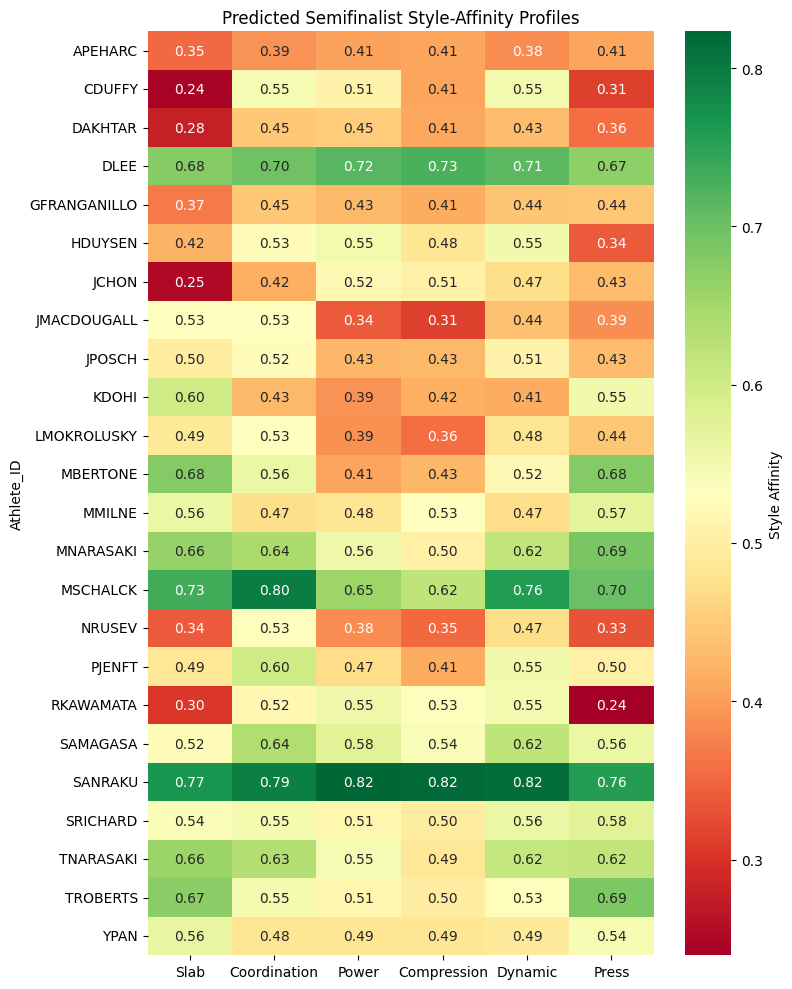

In [ ]:
plot_data = predicted_profile_shrunk.set_index("Athlete_ID")
plot_data.columns = [c.replace("_Affinity_Shrunk", "") for c in plot_data.columns]
plt.figure(figsize=(8, 10))
sns.heatmap(plot_data, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "Style Affinity"})
plt.title("Predicted Semifinalist Style-Affinity Profiles")
plt.tight_layout()
plt.savefig("style_affinity_heatmap.png", dpi=200)
plt.show()